In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qcodes as qc
import pandas as pd
from qcodes.dataset import initialise_database, initialise_or_create_database_at, load_or_create_experiment, plot_dataset
from qcodes.dataset.experiment_container import experiments

from qcodes.dataset.experiment_container import load_experiment_by_name, load_experiment
from qcodes.dataset.data_set import load_by_id


from pathlib import Path

from scipy import stats
import scienceplots

In [2]:
plt.style.use(['science','no-latex'])

plt.rcParams['figure.figsize'] = [10, 6]

In this notebook we will load the bandedges data, subtract the background and make a plot showing how the badedges change for different a (so the gap between the holes in the waveguide structure.)

In [3]:
initialise_or_create_database_at(Path.cwd() / '20251017_4K.db')

We now load all the data with a function. Note that for this dataset we need to reset_index to get all columns.

In [4]:
def load_specfic_dataset(id_number):
    dataset = load_by_id(id_number)
    dataset_pd = dataset.to_pandas_dataframe()
    df_reset = dataset_pd.reset_index()
    return df_reset

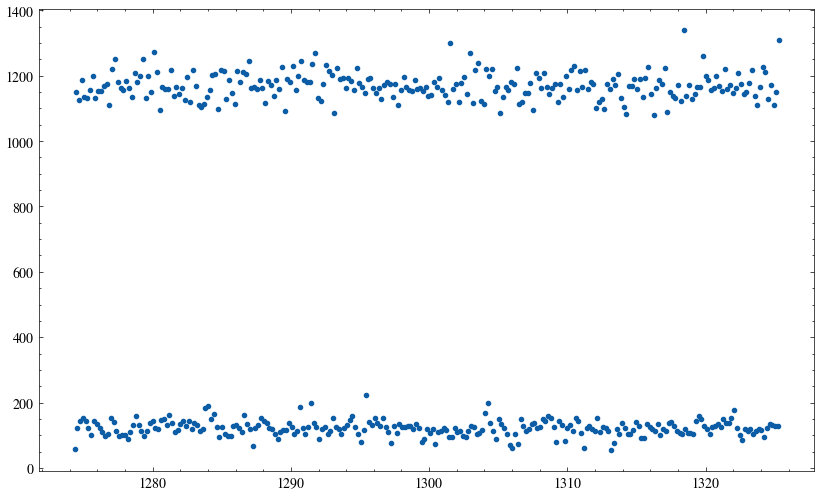

In [5]:
# Loading background

df_background = load_specfic_dataset(1)
plt.plot(df_background['Shamrock_calibration'], df_background['Andor_spectrum'],".")
plt.show()

peak_index: 115
     Shamrock_calibration  Andor_spectrum  Andor_spectrum_bg_subtracted
141           1288.544922          1480.0                         308.0
142           1288.645142           339.0                         219.0
143           1288.745605          1323.0                         186.0
144           1288.845825           240.0                         136.0
145           1288.946045          1323.0                         135.0
..                    ...             ...                           ...
507           1324.923584          1109.0                           0.0
508           1325.021851           123.0                          -4.0
509           1325.120361          1147.0                          -3.0
510           1325.218872           130.0                           3.0
511           1325.317139          1302.0                          -6.0

[371 rows x 3 columns]
bandedge_value_wavelength: 1288.544921875


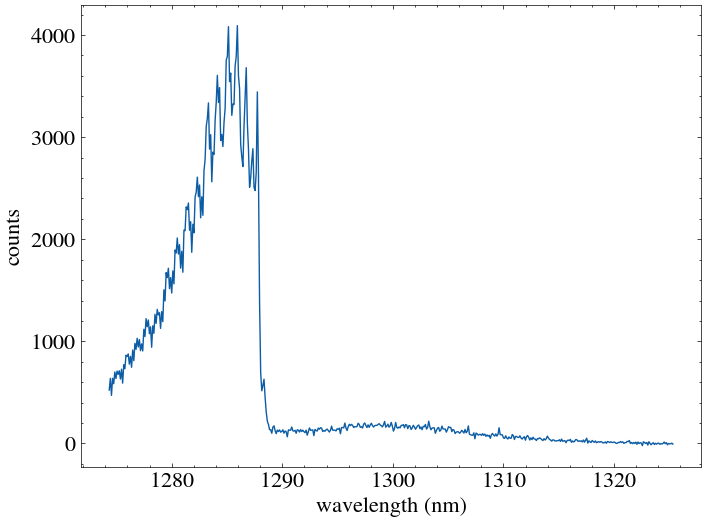

In [6]:
# loading test example and subtracting background 
df_test = load_specfic_dataset(2)
df_test['Andor_spectrum_bg_subtracted'] = df_test['Andor_spectrum'] - df_background['Andor_spectrum']

peak_index = df_test['Andor_spectrum_bg_subtracted'].idxmax()
print("peak_index:",peak_index)
threshold = 0.1 * np.max(df_test['Andor_spectrum_bg_subtracted'])

# creating a mask for values below the threshold and after the peak value
mask = (df_test.index > peak_index) & (df_test['Andor_spectrum_bg_subtracted'] <= threshold)

df_filtered = df_test[mask]
print(df_filtered)
# take the first value that meets the criteria

if not df_filtered.empty:
    bandedge_value_wav = df_filtered.iloc[0]["Shamrock_calibration"]
    print("bandedge_value_wavelength:", bandedge_value_wav)

plt.figure(figsize = (8, 6))
plt.plot(df_test['Shamrock_calibration'], df_test['Andor_spectrum_bg_subtracted'])
#plt.axhline(y=threshold, color='r', linestyle='--')
plt.xlabel("wavelength (nm)", fontsize = 16)
plt.ylabel("counts", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.savefig("plots/bandedges_example.png", dpi = 300)
plt.show()

In [7]:
def threshold_finder(df, threshold = 0.1):
    peak_index = df['Andor_spectrum_bg_subtracted'].idxmax()
    threshold_value = threshold * np.max(df['Andor_spectrum_bg_subtracted'])
    mask = (df.index > peak_index) & (df['Andor_spectrum_bg_subtracted'] <= threshold_value)
    df_filtered = df[mask]
    if not df_filtered.empty:
        bandedge_value_wav = df_filtered.iloc[0]["Shamrock_calibration"]
        print("bandedge_value_wavelength:", bandedge_value_wav)
        return bandedge_value_wav

[2 3 4 5 6]
bandedge_value_wavelength: 1288.74560546875


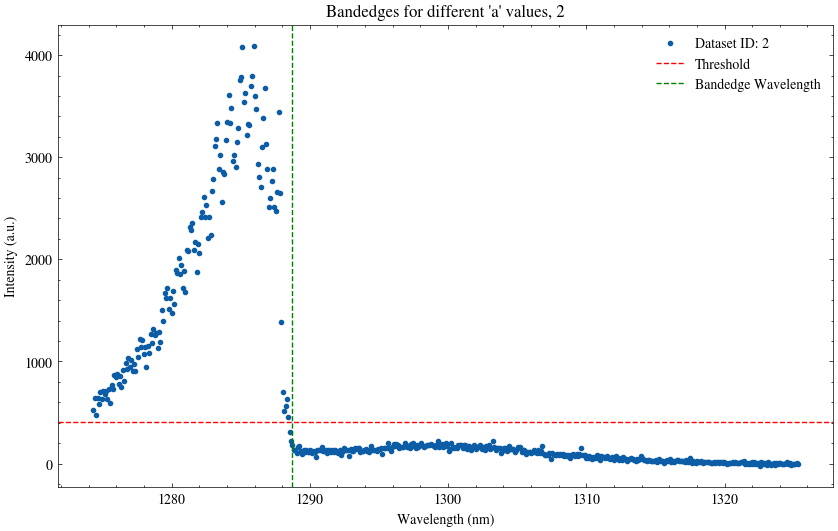

bandedge_value_wavelength: 1296.95495605469


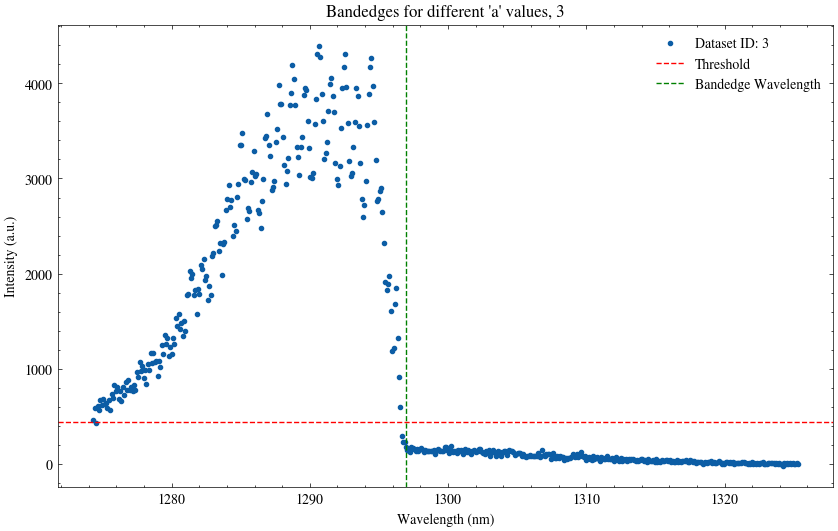

bandedge_value_wavelength: 1301.9443359375


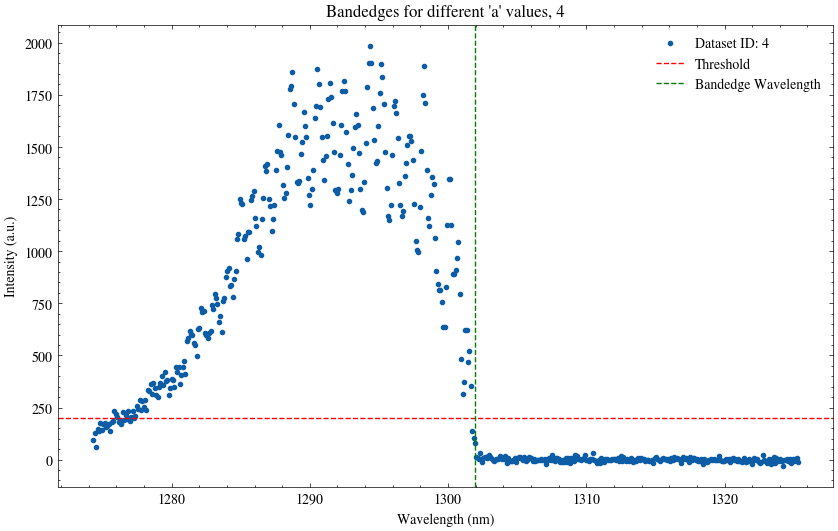

bandedge_value_wavelength: 1305.23010253906


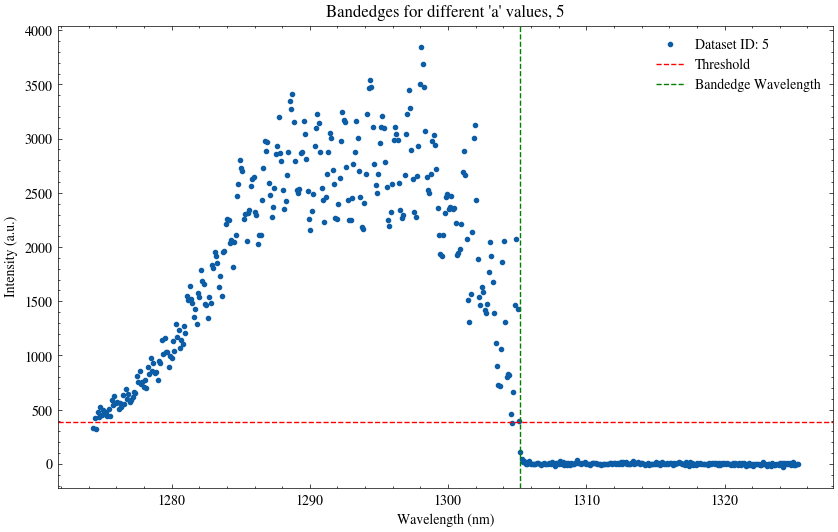

bandedge_value_wavelength: 1313.66760253906


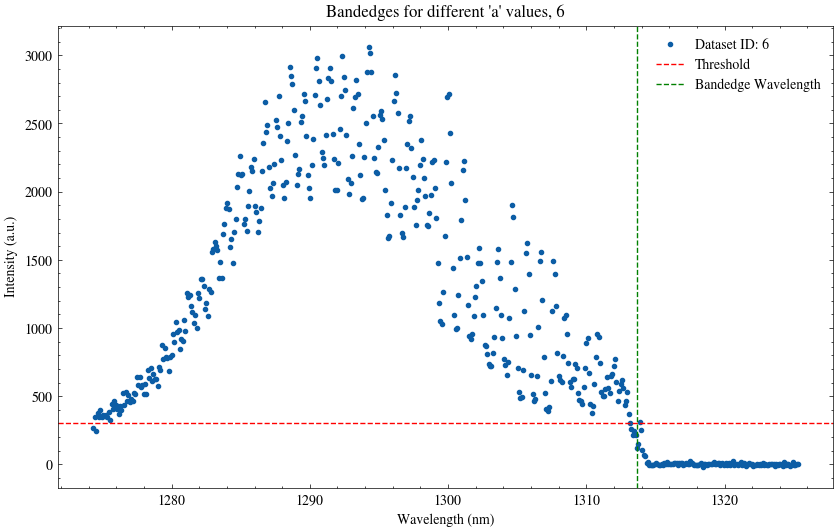

In [8]:
badedges_numbers = np.arange(2, 7)
print(badedges_numbers)
threshold_list = []
for number in badedges_numbers:
    df_reset = load_specfic_dataset(number)
    df_reset['Andor_spectrum_bg_subtracted'] = df_reset['Andor_spectrum'] - df_background['Andor_spectrum']
    threshold_y = 0.10 * np.max(df_reset['Andor_spectrum_bg_subtracted'])
   
    #finding bandedge wavelength

    bandedge_wavelength = threshold_finder(df_reset, threshold=0.05)
    threshold_list.append(bandedge_wavelength)

    plt.plot(df_reset['Shamrock_calibration'], df_reset['Andor_spectrum_bg_subtracted'], ".", label=f"Dataset ID: {number}")
    plt.axhline(y=threshold_y, color='r', linestyle='--', label='Threshold')
    plt.axvline(x=bandedge_wavelength, color='g', linestyle='--', label='Bandedge Wavelength')
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(f"Bandedges for different 'a' values, {number}")
    plt.legend()
    plt.show()

#dataset = load_by_id(6)

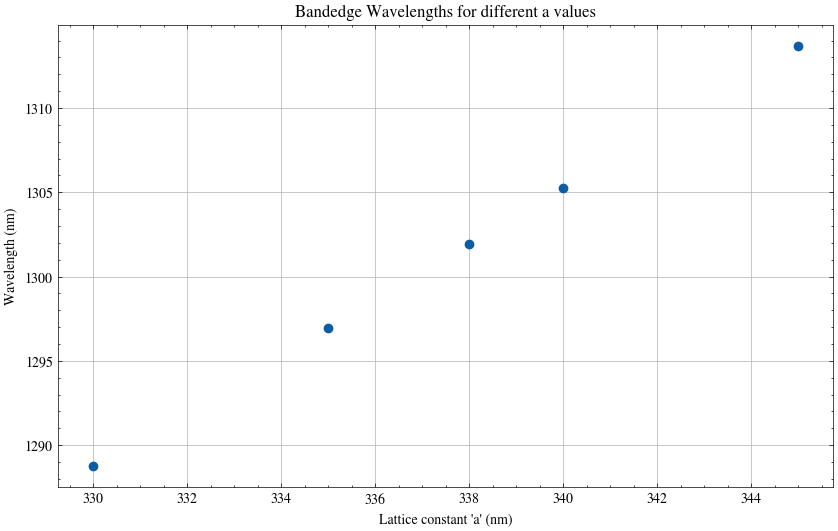

In [9]:
# Now we try to plot the bandedges for all a values on one plot. 

# Now make a list of the different lattice constants 'a' corresponding to each dataset ID

a_values = [330, 335, 338, 340, 345] # in nm

plt.plot(a_values, threshold_list, "o")
plt.xlabel("Lattice constant 'a' (nm)")
plt.ylabel("Wavelength (nm)")
plt.title("")
plt.grid()
plt.title("Bandedge Wavelengths for different a values")
plt.show()

In [10]:
slope, intercept, r_value, p_value, std_err = stats.linregress(a_values, threshold_list)

print(f"Slope: {slope}, Intercept: {intercept}, R-squared: {r_value**2}")

Slope: 1.6607088814144884, Intercept: 740.6532021422805, R-squared: 0.9999580265359798


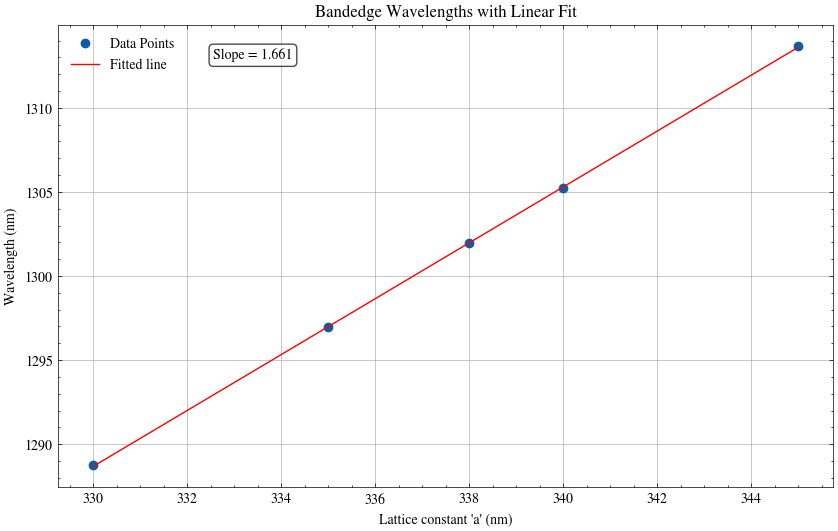

In [11]:
# plot the linear fit on top of the data points

plt.plot(a_values, threshold_list, "o", label="Data Points")
plt.plot(a_values, intercept + slope * np.array(a_values), 'r', label='Fitted line')
plt.xlabel("Lattice constant 'a' (nm)")
plt.ylabel("Wavelength (nm)")
plt.title("Bandedge Wavelengths with Linear Fit")
plt.text(
    0.2, 0.95,
    f"Slope = {slope:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)
plt.legend()
plt.grid()
plt.show()